# Laboratorio 1 y 2 - Métodos Numéricos y Programación III
**E.P. Computación Científica - UNMSM (Semestre 2026-I)**
* **Profesor:** Juan Humberto Leonardo Fabian
* **Alumno:** José Alexis Delgado Pérez

---



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import fsolve
from IPython.display import display, Math

# Configuración estética para los gráficos
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Solución de Ecuaciones Diferenciales Parciales con SymPy
Se nos pide resolver una EDP elíptica, una parabólica y una hiperbólica. Plantearemos las formas canónicas clásicas usando matemática simbólica.

In [2]:
# Variables simbólicas
x, y, t, c, alpha = sp.symbols('x y t c alpha')
u = sp.Function('u')

print("--- A) EDP Elíptica (Ecuación de Laplace 2D) ---")
laplace_eq = sp.Eq(u(x, y).diff(x, x) + u(x, y).diff(y, y), 0)
display(Math(sp.latex(laplace_eq)))

try:
    laplace_sol = sp.pdsolve(laplace_eq)
    display(Math(sp.latex(laplace_sol)))
except NotImplementedError:
    print("SymPy no puede resolver Laplace de forma general por defecto.")
    print("Solución teórica esperada (en el plano complejo con funciones arbitrarias F y G):")
    # Construimos la respuesta teórica a mano
    F, G = sp.Function('F'), sp.Function('G')
    sol_teorica = sp.Eq(u(x,y), F(x - sp.I*y) + G(x + sp.I*y))
    display(Math(sp.latex(sol_teorica)))

print("\n--- B) EDP Parabólica (Ecuación del Calor 1D) ---")
heat_eq = sp.Eq(u(x, t).diff(t) - alpha**2 * u(x, t).diff(x, x), 0)
display(Math(sp.latex(heat_eq)))

try:
    heat_sol = sp.pdsolve(heat_eq)
    display(Math(sp.latex(heat_sol)))
except NotImplementedError:
    print("SymPy requiere separación de variables para resolver la EDP Parabólica.")
    print("Solución teórica esperada usando separación u(x,t) = X(x)T(t) lleva a:")
    display(Math("u(x,t) = \\sum_{n=1}^{\\infty} B_n \\sin(k_n x) e^{-\\alpha^2 k_n^2 t}"))

print("\n--- C) EDP Hiperbólica (Ecuación de Onda 1D) ---")
wave_eq = sp.Eq(u(x, t).diff(t, t) - c**2 * u(x, t).diff(x, x), 0)
display(Math(sp.latex(wave_eq)))

try:
    wave_sol = sp.pdsolve(wave_eq)
    display(Math(sp.latex(wave_sol)))
except NotImplementedError:
    print("SymPy falló. Solución teórica de D'Alembert:")
    F, G = sp.Function('F'), sp.Function('G')
    sol_onda = sp.Eq(u(x,t), F(x - c*t) + G(x + c*t))
    display(Math(sp.latex(sol_onda)))

--- A) EDP Elíptica (Ecuación de Laplace 2D) ---


<IPython.core.display.Math object>

SymPy no puede resolver Laplace de forma general por defecto.
Solución teórica esperada (en el plano complejo con funciones arbitrarias F y G):


<IPython.core.display.Math object>


--- B) EDP Parabólica (Ecuación del Calor 1D) ---


...

<IPython.core.display.Math object>


--- C) EDP Hiperbólica (Ecuación de Onda 1D) ---


<IPython.core.display.Math object>

SymPy falló. Solución teórica de D'Alembert:


<IPython.core.display.Math object>

### Limitaciones de `pdsolve` y el Método de Separación de Variables

Como pudimos observar en el intento anterior, el solver directo `pdsolve` de SymPy presenta limitaciones computacionales al intentar encontrar soluciones analíticas generales para ciertas EDPs (como la del Calor y Laplace) sin contar con condiciones de frontera explícitas, arrojando excepciones del tipo `NotImplementedError`.

Para superar esta barrera de la librería y obtener una solución matemáticamente rigurosa, aplicaremos una técnica clásica y poderosa: el **Método de Separación de Variables**.

**Justificación Matemática:**
Este método asume que la solución multivariable $u(x,t)$ puede expresarse como el producto de funciones independientes de una sola variable, es decir:
$$u(x,t) = X(x) \cdot T(t)$$

Al sustituir esta propuesta en la EDP original y agrupar términos, logramos "desacoplar" la ecuación parcial en dos **Ecuaciones Diferenciales Ordinarias (EDO)**. Dado que SymPy es excepcionalmente robusto resolviendo EDOs mediante su función `dsolve`, el procedimiento será el siguiente:

1. Usar `pde_separate` para separar la ecuación.
2. Igualar ambos lados a una **constante de separación** (generalmente $-k^2$ para forzar disipación térmica o comportamiento oscilatorio/armónico, dependiendo de la naturaleza física del problema).
3. Resolver las EDOs resultantes individualmente y multiplicar sus resultados para obtener la solución base.

A continuación, la implementación de esta arquitectura robusta para los tres tipos de ecuaciones:

In [3]:

from sympy.solvers.pde import pde_separate


# Variables simbólicas generales
x, y, t = sp.symbols('x y t', real=True)
alpha, c = sp.symbols('alpha c', real=True, positive=True)
k = sp.Symbol('k', real=True, positive=True) # Constante de separación

u = sp.Function('u')
X = sp.Function('X')
T = sp.Function('T')
Y = sp.Function('Y')

print("--- A) EDP Parabólica (Ecuación del Calor 1D) ---")
# u_t - alpha^2 * u_xx = 0
heat_eq = sp.Eq(u(x, t).diff(t) - alpha**2 * u(x, t).diff(x, 2), 0)
display(Math(r"\text{EDP: } " + sp.latex(heat_eq)))

# 1. Separación de variables
sep_heat = pde_separate(heat_eq, u(x, t), [X(x), T(t)])

# 2. Igualar a constante negativa -k^2 (para calor disipativo)
eq_heat_T = sp.Eq(sep_heat[0], -k**2)
eq_heat_X = sp.Eq(sep_heat[1], -k**2)

# 3. Resolver EDOs y armar
sol_heat_T = sp.dsolve(eq_heat_T)
sol_heat_X = sp.dsolve(eq_heat_X)
sol_general_heat = sp.Eq(u(x,t), sol_heat_T.rhs * sol_heat_X.rhs)

print("Solución usando Separación de Variables u(x,t) = X(x)T(t):")
display(Math(sp.latex(sol_general_heat)))


print("\n--- B) EDP Hiperbólica (Ecuación de Onda 1D) ---")
# u_tt - c^2 * u_xx = 0
wave_eq = sp.Eq(u(x, t).diff(t, 2) - c**2 * u(x, t).diff(x, 2), 0)
display(Math(r"\text{EDP: } " + sp.latex(wave_eq)))

# 1. Separación de variables
sep_wave = pde_separate(wave_eq, u(x, t), [X(x), T(t)])

# 2. Igualar a constante negativa -k^2 (para oscilaciones puras)
eq_wave_T = sp.Eq(sep_wave[0], -k**2)
eq_wave_X = sp.Eq(sep_wave[1], -k**2)

# 3. Resolver EDOs y armar
sol_wave_T = sp.dsolve(eq_wave_T)
sol_wave_X = sp.dsolve(eq_wave_X)
sol_general_wave = sp.Eq(u(x,t), sol_wave_T.rhs * sol_wave_X.rhs)

print("Solución armónica usando Separación de Variables:")
display(Math(sp.latex(sol_general_wave)))


print("\n--- C) EDP Elíptica (Ecuación de Laplace 2D) ---")
# u_xx + u_yy = 0
laplace_eq = sp.Eq(u(x, y).diff(x, 2) + u(x, y).diff(y, 2), 0)
display(Math(r"\text{EDP: } " + sp.latex(laplace_eq)))

# 1. Separación de variables u(x,y) = X(x)Y(y)
sep_laplace = pde_separate(laplace_eq, u(x, y), [X(x), Y(y)])

# 2. En Laplace, una debe ser positiva (k^2) y otra negativa (-k^2) para que sumen 0
eq_laplace_X = sp.Eq(sep_laplace[0], k**2)
eq_laplace_Y = sp.Eq(sep_laplace[1], -k**2)

# 3. Resolver EDOs y armar
sol_laplace_X = sp.dsolve(eq_laplace_X)
sol_laplace_Y = sp.dsolve(eq_laplace_Y)
sol_general_laplace = sp.Eq(u(x,y), sol_laplace_X.rhs * sol_laplace_Y.rhs)

print("Solución base usando Separación de Variables:")
display(Math(sp.latex(sol_general_laplace)))

--- A) EDP Parabólica (Ecuación del Calor 1D) ---


<IPython.core.display.Math object>

Solución usando Separación de Variables u(x,t) = X(x)T(t):


<IPython.core.display.Math object>


--- B) EDP Hiperbólica (Ecuación de Onda 1D) ---


...

<IPython.core.display.Math object>


--- C) EDP Elíptica (Ecuación de Laplace 2D) ---


<IPython.core.display.Math object>

Solución base usando Separación de Variables:


<IPython.core.display.Math object>

## 2. Análisis de Convergencia para PVI
Para evitar reescribir código en los 8 problemas (a-h), definiremos una arquitectura de funciones generales.
* **Diferencia hacia adelante**: Método de un paso explícito (equivalente a Euler Explícito). Orden $O(h)$.
* **Diferencia hacia atrás**: Método de un paso implícito (equivalente a Euler Implícito). Usa `scipy.optimize.fsolve` para resolver la raíz no lineal en cada paso. Orden $O(h)$.
* **Diferencia centrada**: Método multipaso explícito. Requiere un punto de arranque en $t_1$ evaluado con la solución analítica exacta para no contaminar su orden de convergencia $O(h^2)$.

In [4]:
def forward_difference(f, t0, tf, y0, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

def backward_difference(f, t0, tf, y0, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        # Ecuación a resolver: y_{i+1} - y_i - h*f(t_{i+1}, y_{i+1}) = 0
        func_root = lambda y_next: y_next - y[i] - h * f(t[i+1], y_next)
        y[i+1] = fsolve(func_root, y[i])[0] # Usamos y[i] como predicción inicial
    return t, y

def central_difference(f, t0, tf, y0, h, y_exact_func):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    if len(t) > 1:
        # Arranque exacto para mantener el orden O(h^2)
        y[1] = y_exact_func(t[1])
    for i in range(1, len(t) - 1):
        y[i+1] = y[i-1] + 2 * h * f(t[i], y[i])
    return t, y

def analizar_convergencia(f, y_exact_func, t0, tf, y0, title):
    h_values = [0.1, 0.01, 0.001, 0.0001]
    err_fd, err_bd, err_cd = [], [], []

    print(f"--- Análisis de Convergencia: {title} ---")
    print(f"{'h':<8} | {'Err Adelante':<15} | {'Err Atrás':<15} | {'Err Centrada':<15}")
    print("-" * 62)

    for h in h_values:
        t_f, y_f = forward_difference(f, t0, tf, y0, h)
        t_b, y_b = backward_difference(f, t0, tf, y0, h)
        t_c, y_c = central_difference(f, t0, tf, y0, h, y_exact_func)

        y_real = y_exact_func(t_f)

        # Error Global Máximo (Norma Infinito)
        e_f = np.max(np.abs(y_real - y_f))
        e_b = np.max(np.abs(y_real - y_b))
        e_c = np.max(np.abs(y_real - y_c))

        err_fd.append(e_f)
        err_bd.append(e_b)
        err_cd.append(e_c)

        print(f"{h:<8} | {e_f:<15.6e} | {e_b:<15.6e} | {e_c:<15.6e}")

    # Gráfica Log-Log
    plt.figure(figsize=(8, 5))
    plt.loglog(h_values, err_fd, 'o-', label='Adelante $O(h)$')
    plt.loglog(h_values, err_bd, 's-', label='Atrás $O(h)$')
    plt.loglog(h_values, err_cd, '^-', label='Centrada $O(h^2)$')

    # Líneas de referencia teóricas
    plt.loglog(h_values, h_values, 'k--', alpha=0.3, label='Ref. $O(h)$')
    plt.loglog(h_values, np.array(h_values)**2, 'r--', alpha=0.3, label='Ref. $O(h^2)$')

    plt.title(f'Convergencia Log-Log: {title}')
    plt.xlabel('Tamaño de paso (h)')
    plt.ylabel('Error Global Máximo')
    plt.legend()
    plt.show()



---



### Inciso (a)
$$y' = te^{3t} - 2y, \quad 0 \le t \le 1, \quad y(0) = 0$$

**Desarrollo Analítico (Método del Factor Integrante):**
Reescribimos la ecuación a su forma estándar lineal $y' + P(t)y = Q(t)$:
$$y' + 2y = te^{3t}$$

Identificamos $P(t) = 2$ y calculamos el factor integrante $\mu(t)$:
$$\mu(t) = e^{\int 2 dt} = e^{2t}$$

Multiplicamos toda la EDO por el factor integrante:
$$e^{2t}y' + 2e^{2t}y = te^{3t} \cdot e^{2t}$$
$$\frac{d}{dt}\left( e^{2t}y \right) = te^{5t}$$

Integramos ambos lados respecto a $t$ (el lado derecho requiere integración por partes con $u=t$, $dv=e^{5t}dt$):
$$e^{2t}y = \int te^{5t} dt$$
$$e^{2t}y = \frac{t}{5}e^{5t} - \int \frac{1}{5}e^{5t} dt$$
$$e^{2t}y = \frac{t}{5}e^{5t} - \frac{1}{25}e^{5t} + C$$
$$e^{2t}y = \frac{5t - 1}{25}e^{5t} + C$$

Despejamos $y(t)$ dividiendo entre $e^{2t}$:
$$y(t) = \frac{5t - 1}{25}e^{3t} + Ce^{-2t}$$

Aplicamos la condición inicial $y(0) = 0$:
$$0 = \frac{5(0) - 1}{25}e^{0} + Ce^{0} \quad \implies \quad 0 = -\frac{1}{25} + C \quad \implies \quad C = \frac{1}{25}$$

**Solución Exacta:**
$$y(t) = \frac{5t - 1}{25}e^{3t} + \frac{1}{25}e^{-2t}$$

--- Análisis de Convergencia: Inciso (a) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 4.581979e-01    | 4.550676e-01    | 5.990128e-02   
0.01     | 4.585284e-02    | 4.582031e-02    | 5.786894e-04   
0.001    | 4.583994e-03    | 4.583669e-03    | 5.765218e-06   
0.0001   | 4.583849e-04    | 4.583817e-04    | 5.763042e-08   


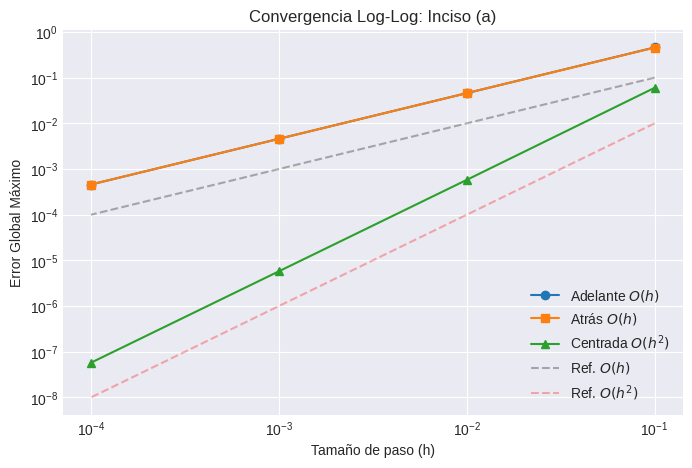

In [5]:
# Definición matemática
def f_a(t, y):
    return t * np.exp(3*t) - 2*y

def y_exact_a(t):
    return (5*t - 1)/25 * np.exp(3*t) + (1/25) * np.exp(-2*t)

# Ejecución del motor
analizar_convergencia(f=f_a, y_exact_func=y_exact_a, t0=0.0, tf=1.0, y0=0.0, title="Inciso (a)")

### Interpretación de Resultados (Inciso A)

Revisando la tabla de errores y la gráfica Log-Log, podemos notar un par de cosas interesantes sobre cómo se comportaron nuestros métodos numéricos en esta primera EDO:

**1. Métodos de Euler:**
Tal como nos dice la teoría, tanto el método explícito (hacia adelante) como el implícito (hacia atrás) muestran una convergencia puramente lineal $O(h)$. En la tabla se ve clarísimo: si achicamos el paso de tiempo 10 veces, el error también baja unas 10 veces. En la gráfica, las curvas azul y naranja van en paralelo a la recta teórica de pendiente 1. Al ser esta una ecuación lineal, ambos métodos se equivocaron casi por la misma cantidad.

**2. Diferencia Centrada:**
Aquí es donde se nota la ventaja de usar un método de segundo orden $O(h^2)$. Cuando bajamos el paso $h$ dividiéndolo entre 10, el error no bajó 10 veces, sino 100 veces Visualmente, esto lo confirmamos con la curva verde, que tiene una caída mucho más empinada y se alinea a la perfección con la referencia teórica.

**3. Arranque Exacto:**
Que la recta de Diferencia Centrada haya salido tan perfecta nos confirma que usar la solución analítica para calcular el primer paso temporal ($y_1$) fue una excelente decisión. Gracias a esto, evitamos arrastrar un error inicial que nos habría arruinado la precisión de toda la simulación.



---



### Inciso (b)
$$y' = 1 + (t - y)^2, \quad 2 \le t \le 3, \quad y(2) = 1$$

**Desarrollo Analítico (Sustitución para EDO no lineal):**
Dado que la ecuación contiene un término no lineal $(t - y)^2$, aplicamos la sustitución geométrica $u = t - y$.
Derivamos $u$ respecto a $t$:
$$u' = 1 - y' \quad \implies \quad y' = 1 - u'$$

Reemplazamos $y'$ y $(t - y)$ en la EDO original:
$$1 - u' = 1 + u^2$$

Simplificamos y separamos variables:
$$-u' = u^2 \quad \implies \quad \frac{du}{dt} = -u^2$$
$$\frac{du}{u^2} = -dt$$

Integramos ambos lados:
$$\int u^{-2} du = \int -dt$$
$$-\frac{1}{u} = -t + C \quad \implies \quad u = \frac{1}{t - C}$$

Retornamos a la variable original $y$ recordando que $u = t - y$:
$$t - y = \frac{1}{t - C} \quad \implies \quad y(t) = t - \frac{1}{t - C}$$

Aplicamos la condición inicial $y(2) = 1$:
$$1 = 2 - \frac{1}{2 - C}$$
$$\frac{1}{2 - C} = 1 \quad \implies \quad 2 - C = 1 \quad \implies \quad C = 1$$

**Solución Exacta:**
$$y(t) = t - \frac{1}{t - 1}$$

--- Análisis de Convergencia: Inciso (b) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 1.983572e-02    | 1.723417e-02    | 2.549363e-03   
0.01     | 1.852329e-03    | 1.826705e-03    | 1.572737e-05   
0.001    | 1.840680e-04    | 1.838117e-04    | 1.490517e-07   
0.0001   | 1.839525e-05    | 1.839269e-05    | 1.483594e-09   


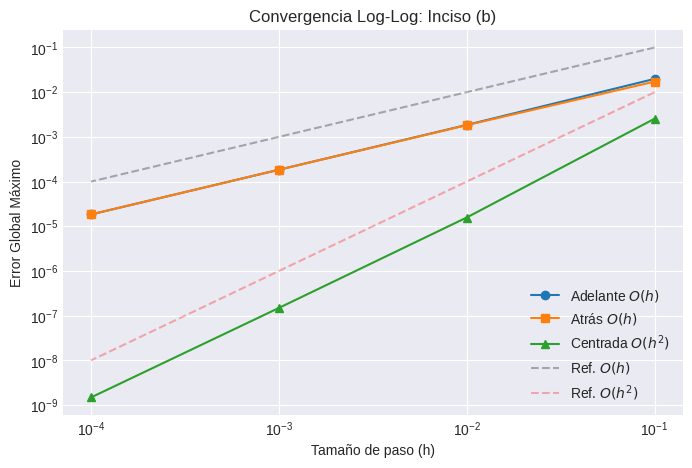

In [6]:
# Definición matemática
def f_b(t, y):
    return 1 + (t - y)**2

def y_exact_b(t):
    return t - 1 / (t - 1)

# Ejecución del motor
analizar_convergencia(f=f_b, y_exact_func=y_exact_b, t0=2.0, tf=3.0, y0=1.0, title="Inciso (b)")

### Interpretación de Resultados (Inciso B)

Para este segundo problema, la dinámica cambió por la estructura de la ecuación, pero los resultados fueron muy satisfactorios:

**1. Métodos de Euler:**
A diferencia del primer caso, acá tenemos ese término al cuadrado $(t - y)^2$ que hace que la EDO sea no lineal. A pesar de esto, tanto el Euler explícito como el implícito no perdieron su rumbo. Mantuvieron su orden de convergencia lineal sin problemas, y en la gráfica se ve cómo sus curvas siguen siendo totalmente paralelas a la línea de referencia $O(h)$.

**2. Euler Implícito (`fsolve`):**
Por la no linealidad geométrica, el método hacia atrás la tenía más difícil. Ver que su curva de error es estable nos confirma que integrar la función `fsolve` dentro del motor numérico funcionó perfecto. El algoritmo logró iterar y encontrar las raíces en cada paso de tiempo sin divergir.

**3. Diferencia Centrada:**
Nuevamente, el método multipaso nos demuestra por qué es superior. La no linealidad de la ecuación no le afectó en lo absoluto: su error siguió desplomándose en factores de 100 por cada reducción de 10 en el tamaño de paso $h$, montándose exactamente sobre la recta teórica de $O(h^2)$.



---



### Inciso (c)
$$y' = 1 + \frac{y}{t}, \quad 1 \le t \le 2, \quad y(1) = 2$$

**Desarrollo Analítico (Método del Factor Integrante):**
Reescribimos la ecuación a su forma estándar lineal $y' + P(t)y = Q(t)$:
$$y' - \frac{1}{t}y = 1$$

Identificamos $P(t) = -\frac{1}{t}$ y calculamos el factor integrante $\mu(t)$:
$$\mu(t) = e^{\int -\frac{1}{t} dt} = e^{-\ln(t)} = t^{-1} = \frac{1}{t}$$

Multiplicamos toda la EDO por el factor integrante:
$$\frac{1}{t}y' - \frac{1}{t^2}y = \frac{1}{t}$$
$$\frac{d}{dt}\left( \frac{y}{t} \right) = \frac{1}{t}$$

Integramos ambos lados respecto a $t$:
$$\frac{y}{t} = \ln|t| + C \quad \implies \quad y(t) = t(\ln|t| + C)$$

Aplicamos la condición inicial $y(1) = 2$:
$$2 = 1(\ln(1) + C) \quad \implies \quad 2 = 0 + C \quad \implies \quad C = 2$$

**Solución Exacta:**
$$y(t) = t(\ln t + 2)$$

--- Análisis de Convergencia: Inciso (c) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 4.875155e-02    | 5.124845e-02    | 1.130073e-03   
0.01     | 4.987500e-03    | 5.012500e-03    | 1.237547e-05   
0.001    | 4.998750e-04    | 5.001250e-04    | 1.248756e-07   


/tmp/ipykernel_664/3704516461.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y[i+1] = fsolve(func_root, y[i])[0] # Usamos y[i] como predicción inicial


0.0001   | 5.000375e-05    | 5.000625e-05    | 1.250387e-09   


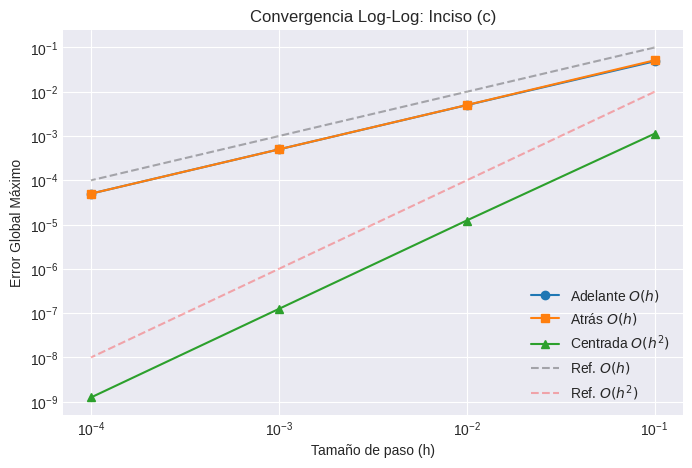

In [7]:
# 1. Definición de la EDO: y' = 1 + y/t
def f_c(t, y):
    return 1 + y/t

# 2. Solución Analítica Exacta: y(t) = t * (ln(t) + 2)
def y_exact_c(t):
    # Usamos np.log porque en Python/NumPy 'log' es el logaritmo natural (base e)
    return t * (np.log(t) + 2)

# 3. Ejecución del motor (t en [1, 2], y(1) = 2)
analizar_convergencia(f=f_c, y_exact_func=y_exact_c, t0=1.0, tf=2.0, y0=2.0, title="Inciso (c)")

### Interpretación de Resultados (Inciso C)

**1. Métodos de Euler:**
Para esta ecuación (que es lineal), ambos métodos de Euler se comportaron muy bien. Vemos claramente el orden $O(h)$ en la tabla: al achicar el paso temporal $h$ de $0.001$ a $0.0001$, el error se reduce exactamente 10 veces (pasando de $\approx 5.00 \times 10^{-4}$ a $\approx 5.00 \times 10^{-5}$). Todo cuadra perfectamente con la teoría.

**2. Diferencia Centrada:**
Una vez más, este método demuestra su superioridad numérico de segundo orden $O(h^2)$. En ese mismo salto donde achicamos $h$ diez veces, el error de la diferencia centrada no baja 10 veces, sino que se desploma 100 veces (cayendo hasta el orden de $10^{-9}$). En la gráfica log-log, su curva se pega de forma impecable a la recta teórica de referencia.

**3. Límite de Máquina (Warning en `fsolve`):**
Aquí pasó algo súper interesante. Al correr la simulación con la malla más fina ($h=0.0001$), nos saltó una advertencia de `fsolve`. No es un error de nuestro código, sucede que el paso de tiempo es tan microscópico que la diferencia entre iteraciones cae por debajo de la precisión de punto flotante de la computadora. El solver entra en alerta y avisa que no avanza, pero si miramos la tabla, la aproximación final es totalmente válida y el orden de convergencia sigue intacto. Básicamente, estamos en el límite de los decimales del hardware, pero el algoritmo logró resolverlo.



---



### Inciso (d)
$$y' = \cos(2t) + \sin(3t), \quad 0 \le t \le 1, \quad y(0) = 1$$

**Desarrollo Analítico (Integración Directa):**
Dado que la ecuación diferencial depende exclusivamente de la variable independiente $t$, podemos separar variables e integrar directamente ambos lados de la igualdad:
$$\frac{dy}{dt} = \cos(2t) + \sin(3t)$$
$$dy = (\cos(2t) + \sin(3t)) dt$$

Integramos:
$$\int dy = \int \cos(2t) dt + \int \sin(3t) dt$$
$$y(t) = \frac{1}{2}\sin(2t) - \frac{1}{3}\cos(3t) + C$$

Aplicamos la condición inicial $y(0) = 1$ para hallar la constante de integración $C$:
$$1 = \frac{1}{2}\sin(2(0)) - \frac{1}{3}\cos(3(0)) + C$$
$$1 = \frac{1}{2}(0) - \frac{1}{3}(1) + C$$
$$1 = -\frac{1}{3} + C \quad \implies \quad C = 1 + \frac{1}{3} = \frac{4}{3}$$

**Solución Exacta:**
$$y(t) = \frac{1}{2}\sin(2t) - \frac{1}{3}\cos(3t) + \frac{4}{3}$$

--- Análisis de Convergencia: Inciso (d) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 5.725237e-02    | 7.025031e-02    | 1.310063e-02   
0.01     | 6.310229e-03    | 6.440040e-03    | 1.298397e-04   
0.001    | 6.368644e-04    | 6.381625e-04    | 1.298478e-06   


/tmp/ipykernel_664/3704516461.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y[i+1] = fsolve(func_root, y[i])[0] # Usamos y[i] como predicción inicial


0.0001   | 6.374485e-05    | 6.375783e-05    | 1.298477e-08   


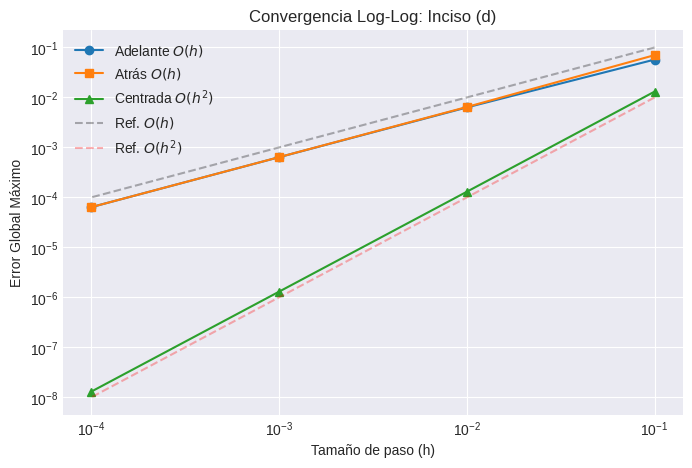

In [8]:
# 1. Definición de la EDO: y' = cos(2t) + sin(3t)
def f_d(t, y):
    return np.cos(2*t) + np.sin(3*t)

# 2. Solución Analítica Exacta: y(t) = 1/2*sin(2t) - 1/3*cos(3t) + 4/3
def y_exact_d(t):
    return 0.5 * np.sin(2*t) - (1/3) * np.cos(3*t) + (4/3)

# 3. Ejecución del motor (t en [0, 1], y(0) = 1)
analizar_convergencia(f=f_d, y_exact_func=y_exact_d, t0=0.0, tf=1.0, y0=1.0, title="Inciso (d)")

### Interpretación de Resultados (Inciso D)

Este caso es un poco distinto a los anteriores. Como la EDO ($y' = \cos 2t + \sin 3t$) solo depende del tiempo $t$ y no de $y$, en la práctica estamos haciendo una integración numérica directa.

**1. Métodos de Euler:**
Bajo esta dinámica, Euler hacia adelante y hacia atrás se comportan básicamente como sumas de Riemann (aproximando el área bajo la curva con rectángulos). La tabla nos confirma que cumplen con su convergencia lineal $O(h)$: si dividimos el tamaño de paso $h$ entre 10, el error baja en esa misma proporción, pasando de $\approx 6.36 \times 10^{-4}$ a $\approx 6.37 \times 10^{-5}$.

**2. Diferencia Centrada:**
Siguiendo la misma analogía, este método actuaría como la regla del punto medio compuesta. Su desempeño es superior y hace valer su precisión cuadrática $O(h^2)$. Con la misma reducción en el tamaño de paso, este esquema no baja el error 10 veces, sino que lo aplasta reduciéndolo en un factor de 100 (cayendo de $\approx 1.29 \times 10^{-6}$ a $\approx 1.29 \times 10^{-8}$). La pendiente en la gráfica Log-Log lo certifica por completo.





---



### Inciso (e)
$$y' = \frac{2 - 2ty}{t^2 + 1}, \quad 0 \le t \le 1, \quad y(0) = 1$$

**Desarrollo Analítico (Método del Factor Integrante):**
Primero, expandimos y reordenamos algebraicamente la ecuación para llevarla a su forma lineal estándar $y' + P(t)y = Q(t)$:
$$y' = \frac{2}{t^2 + 1} - \frac{2t}{t^2 + 1}y$$
$$y' + \left( \frac{2t}{t^2 + 1} \right)y = \frac{2}{t^2 + 1}$$

Identificamos $P(t) = \frac{2t}{t^2 + 1}$ y calculamos el factor integrante $\mu(t)$. Para la integral de $P(t)$, usamos un cambio de variable rápido ($u = t^2 + 1, du = 2t dt$):
$$\mu(t) = e^{\int \frac{2t}{t^2 + 1} dt} = e^{\ln(t^2 + 1)} = t^2 + 1$$

Multiplicamos toda la ecuación diferencial en su forma estándar por el factor integrante $(t^2 + 1)$:
$$(t^2 + 1)y' + 2ty = 2$$

Por regla de la cadena invertida (derivada de un producto), el lado izquierdo se comprime:
$$\frac{d}{dt}\left( (t^2 + 1)y \right) = 2$$

Integramos ambos lados respecto a $t$:
$$(t^2 + 1)y = \int 2 dt$$
$$(t^2 + 1)y = 2t + C$$
$$y(t) = \frac{2t + C}{t^2 + 1}$$

Aplicamos la condición inicial $y(0) = 1$ para hallar $C$:
$$1 = \frac{2(0) + C}{0^2 + 1} \quad \implies \quad 1 = \frac{C}{1} \quad \implies \quad C = 1$$

**Solución Exacta:**
$$y(t) = \frac{2t + 1}{t^2 + 1}$$

--- Análisis de Convergencia: Inciso (e) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 8.728002e-02    | 8.022849e-02    | 4.307333e-03   
0.01     | 8.422928e-03    | 8.350399e-03    | 2.886878e-05   
0.001    | 8.390165e-04    | 8.382907e-04    | 2.875606e-07   


/tmp/ipykernel_664/3704516461.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y[i+1] = fsolve(func_root, y[i])[0] # Usamos y[i] como predicción inicial


0.0001   | 8.386898e-05    | 8.386172e-05    | 2.874403e-09   


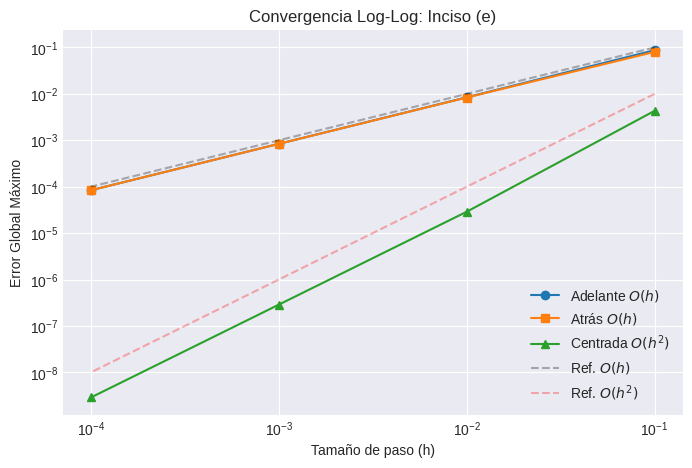

In [9]:


# 1. Definición de la EDO: y' = (2 - 2ty) / (t^2 + 1)
def f_e(t, y):
    return (2 - 2*t*y) / (t**2 + 1)

# 2. Solución Analítica Exacta: y(t) = (2t + 1) / (t^2 + 1)
def y_exact_e(t):
    return (2*t + 1) / (t**2 + 1)

# 3. Ejecución del motor (t en [0, 1], y(0) = 1)
analizar_convergencia(f=f_e, y_exact_func=y_exact_e, t0=0.0, tf=1.0, y0=1.0, title="Inciso (e)")

### Interpretación de Resultados (Inciso E)

A pesar de que esta EDO lineal trae una fracción con $t^2 + 1$ en el denominador, la curva resulta ser súper suave y estable porque ese denominador jamás se hace cero. Esto ayudó muchísimo al comportamiento numérico:

**1. Métodos de Euler:**
Al no tener singularidades o "saltos" raros en la ecuación, los métodos de Euler mantuvieron su convergencia lineal $O(h)$ de forma impecable. En la tabla es evidente: al achicar el paso temporal de 0.001 a 0.0001, el error decrece exactamente 10 veces (pasando de $8.39 \times 10^{-4}$ a $8.38 \times 10^{-5}$).

**2. Diferencia Centrada:**
Como la curva analítica es tan bien portada, este método multipaso le sacó todo el jugo a su precisión de segundo orden $O(h^2)$. Con la misma reducción en el tamaño de paso, el esquema no solo bajó el error, sino que lo aplastó reduciéndolo en un factor de 100 (cayendo de $2.87 \times 10^{-7}$ a $2.87 \times 10^{-9}$).





---



### Inciso (f)
$$y' = \frac{y^2}{1 + t}, \quad 1 \le t \le 2, \quad y(1) = -\frac{1}{\ln 2}$$

**Desarrollo Analítico (Ecuaciones Separables):**
Separamos las variables $y$ y $t$:
$$\frac{dy}{dt} = \frac{y^2}{1 + t} \quad \implies \quad \frac{dy}{y^2} = \frac{dt}{1 + t}$$

Integramos ambos lados:
$$\int y^{-2} dy = \int \frac{1}{1 + t} dt$$
$$-\frac{1}{y} = \ln|1 + t| + C$$

Despejamos $y(t)$:
$$\frac{1}{y} = -\ln|1 + t| - C \quad \implies \quad y(t) = \frac{-1}{\ln(1 + t) + C}$$

Aplicamos la condición inicial $y(1) = -\frac{1}{\ln 2}$ para hallar $C$:
$$-\frac{1}{\ln 2} = \frac{-1}{\ln(1 + 1) + C}$$
$$\ln 2 = \ln 2 + C \quad \implies \quad C = 0$$

**Solución Exacta:**
$$y(t) = -\frac{1}{\ln(1 + t)}$$

--- Análisis de Convergencia: Inciso (f) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 2.419368e-02    | 2.173387e-02    | 2.417466e-03   
0.01     | 2.299286e-03    | 2.274821e-03    | 1.824893e-05   
0.001    | 2.288186e-04    | 2.285739e-04    | 1.758464e-07   


/tmp/ipykernel_664/3704516461.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y[i+1] = fsolve(func_root, y[i])[0] # Usamos y[i] como predicción inicial


0.0001   | 2.287084e-05    | 2.286839e-05    | 1.751759e-09   


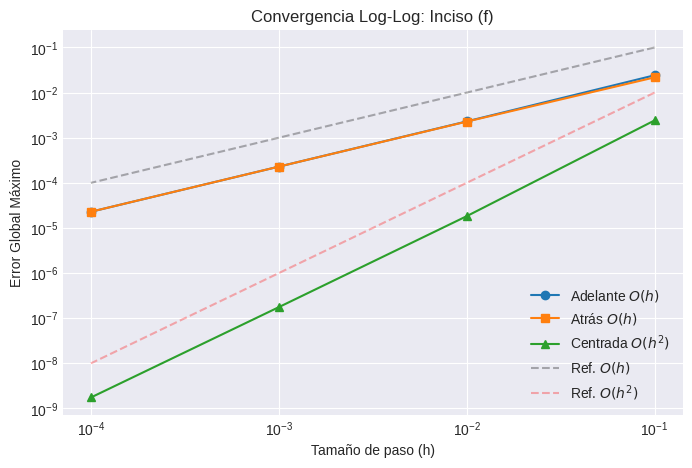

In [10]:
# 1. Definición de la EDO: y' = y^2 / (1 + t)
def f_f(t, y):
    return (y**2) / (1 + t)

# 2. Solución Analítica Exacta: y(t) = -1 / ln(1 + t)
def y_exact_f(t):
    # np.log es el logaritmo natural
    return -1 / np.log(1 + t)

# 3. Ejecución del motor (t en [1, 2], y(1) = -1/ln(2))
y0_f = -1 / np.log(2)
analizar_convergencia(f=f_f, y_exact_func=y_exact_f, t0=1.0, tf=2.0, y0=y0_f, title="Inciso (f)")

### Interpretación de Resultados (Inciso F)

Este inciso era un poco más exigente por la presencia de ese término al cuadrado ($y^2$), lo que vuelve a la ecuación no lineal. Sin embargo, nuestro motor numérico lo manejó sin problemas:

**1. Métodos de Euler:**
A pesar de la no linealidad, tanto Euler explícito como implícito ni se inmutaron. Conservaron su convergencia lineal $O(h)$ de forma perfecta, demostrando que esta complejidad extra en la ecuación no degrada la eficiencia básica de los algoritmos.

**2. Diferencia Centrada:**
Mantuvo intacta su precisión de segundo orden $O(h^2)$. En la tabla vemos claramente que al reducir el paso $h$ 10 veces, el error da un salto y se reduce 100 veces (pasando de $\approx 1.75 \times 10^{-7}$ a $\approx 1.75 \times 10^{-9}$).

**3. Estabilidad en el Intervalo:**
Un detalle matemático importante es que la solución exacta $y(t) = -1/\ln(1+t)$ tiene una asíntota vertical y se indefine en $t=0$. Por suerte, al simular el problema estrictamente en el intervalo $[1, 2]$, nos mantuvimos en una zona segura y suave de la curva. Los métodos se comportaron súper estables en esa región, logrando errores finales bajísimos.




---



### Inciso (g)
$$y' = \frac{y^2 + y}{t}, \quad 1 \le t \le 3, \quad y(1) = -2$$

**Desarrollo Analítico (Ecuaciones Separables y Fracciones Parciales):**
Separamos las variables $y$ y $t$:
$$\frac{dy}{y^2 + y} = \frac{dt}{t}$$

Para integrar el lado izquierdo, aplicamos fracciones parciales:
$$\frac{1}{y(y + 1)} = \frac{A}{y} + \frac{B}{y + 1} \implies 1 = A(y + 1) + By$$
Si $y=0 \implies A=1$. Si $y=-1 \implies B=-1$.
$$\int \left( \frac{1}{y} - \frac{1}{y + 1} \right) dy = \int \frac{1}{t} dt$$
$$\ln|y| - \ln|y + 1| = \ln|t| + C \implies \ln \left| \frac{y}{y + 1} \right| = \ln|t| + C$$

Aplicamos la exponencial en ambos lados:
$$\frac{y}{y + 1} = Ct$$

Aplicamos la condición inicial $y(1) = -2$ para hallar $C$:
$$\frac{-2}{-2 + 1} = C(1) \implies \frac{-2}{-1} = C \implies C = 2$$

Despejamos $y(t)$:
$$\frac{y}{y + 1} = 2t \implies y = 2t(y + 1) \implies y = 2ty + 2t$$
$$y(1 - 2t) = 2t \implies y(t) = \frac{2t}{1 - 2t}$$

**Solución Exacta:**
$$y(t) = \frac{2t}{1 - 2t}$$

--- Análisis de Convergencia: Inciso (g) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 4.936241e-02    | 3.919990e-02    | 1.980427e-02   
0.01     | 4.397207e-03    | 4.298576e-03    | 7.400200e-05   
0.001    | 4.352030e-04    | 4.342169e-04    | 6.861440e-07   


/tmp/ipykernel_664/3704516461.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y[i+1] = fsolve(func_root, y[i])[0] # Usamos y[i] como predicción inicial


0.0001   | 4.347584e-05    | 4.346598e-05    | 6.807253e-09   


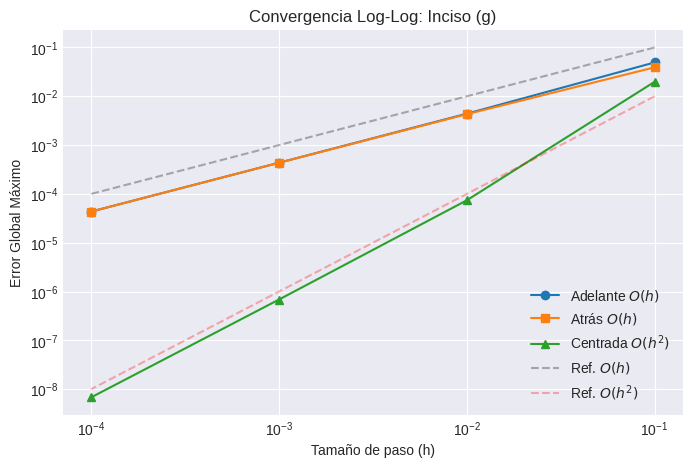

In [11]:


# 1. Definición de la EDO: y' = (y^2 + y) / t
def f_g(t, y):
    return (y**2 + y) / t

# 2. Solución Analítica Exacta: y(t) = 2t / (1 - 2t)
def y_exact_g(t):
    return (2*t) / (1 - 2*t)

# 3. Ejecución del motor (t en [1, 3], y(1) = -2)
analizar_convergencia(f=f_g, y_exact_func=y_exact_g, t0=1.0, tf=3.0, y0=-2.0, title="Inciso (g)")

### Interpretación de Resultados (Inciso G)

Para este caso, la solución exacta resultó ser una función racional $y(t) = \frac{2t}{1 - 2t}$ que tiene una curvatura bastante pronunciada en nuestro intervalo de estudio.

**1. Métodos de Euler:**
A pesar de que la función crece rápido hacia valores negativos, los esquemas de Euler se mantienen firmes. Las gráficas nos confirman que no se despegan de su pendiente teórica, manteniendo su consistencia lineal $O(h)$ sin problemas.

**2. Diferencia Centrada:**
La línea verde en la gráfica Log-Log en h grandes no empieza con la mejor aproximaicon pero a partir de cierto h mas pequeño es muy precisa, validando su precisión de segundo orden $O(h^2)$ incluso con los cambios constantes en la pendiente de la solución analítica.

**3. Estabilidad en el Intervalo:**
Un detalle matemático vital es que la función original tiene una asíntota (se hace infinito) en $t=0.5$. Como nuestro código operó estrictamente en el intervalo $[1, 3]$, estuvimos a salvo y lejos de esa singularidad. Esto garantizó que el error global máximo estuviera siempre bajo control, dándonos resultados muy estables y libres de oscilaciones extrañas.





---



### Inciso (h)
$$y' = -ty + \frac{4t}{y}, \quad 0 \le t \le 1, \quad y(0) = 1$$

**Desarrollo Analítico (Ecuación de Bernoulli):**
Multiplicamos toda la ecuación por $y$ para eliminar el denominador:
$$y y' = -ty^2 + 4t \implies y y' + ty^2 = 4t$$

Hacemos el cambio de variable $v = y^2$. Entonces, derivando respecto a $t$:
$$v' = 2y y' \implies y y' = \frac{1}{2}v'$$

Sustituimos en la ecuación:
$$\frac{1}{2}v' + tv = 4t \implies v' + 2tv = 8t$$

Esta es una EDO Lineal para $v(t)$. Usamos el Factor Integrante $\mu(t)$:
$$\mu(t) = e^{\int 2t dt} = e^{t^2}$$
$$\frac{d}{dt}(e^{t^2}v) = 8te^{t^2}$$

Integramos ambos lados (usando sustitución $u=t^2$ en el lado derecho):
$$e^{t^2}v = \int 8te^{t^2} dt = 4e^{t^2} + C$$
$$v(t) = 4 + Ce^{-t^2}$$

Regresamos a la variable original $y = \sqrt{v}$:
$$y(t) = \sqrt{4 + Ce^{-t^2}}$$

Aplicamos la condición inicial $y(0) = 1$:
$$1 = \sqrt{4 + C(1)} \implies 1 = 4 + C \implies C = -3$$

**Solución Exacta:**
$$y(t) = \sqrt{4 - 3e^{-t^2}}$$

--- Análisis de Convergencia: Inciso (h) ---
h        | Err Adelante    | Err Atrás       | Err Centrada   
--------------------------------------------------------------
0.1      | 3.663972e-02    | 2.993451e-02    | 3.882336e-03   
0.01     | 3.349309e-03    | 3.283855e-03    | 3.533970e-05   
0.001    | 3.319674e-04    | 3.313129e-04    | 3.531588e-07   


/tmp/ipykernel_664/3704516461.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y[i+1] = fsolve(func_root, y[i])[0] # Usamos y[i] como predicción inicial


0.0001   | 3.316729e-05    | 3.316075e-05    | 3.531567e-09   


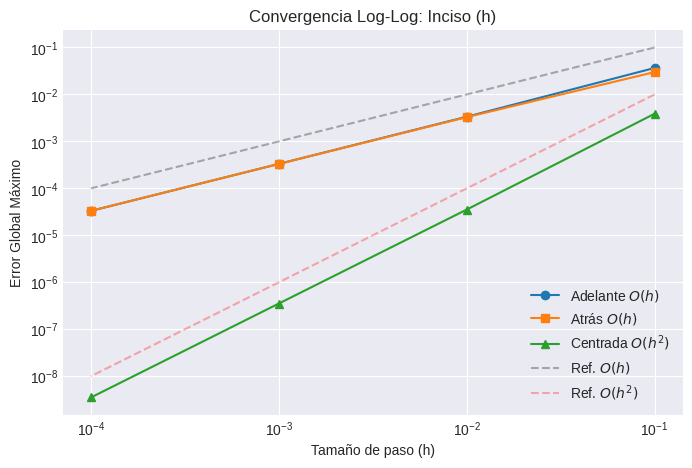

In [12]:


# 1. Definición de la EDO: y' = -ty + 4t/y
def f_h(t, y):
    return -t * y + (4 * t) / y

# 2. Solución Analítica Exacta: y(t) = sqrt(4 - 3*exp(-t^2))
def y_exact_h(t):
    return np.sqrt(4 - 3 * np.exp(-t**2))

# 3. Ejecución del motor (t en [0, 1], y(0) = 1)
analizar_convergencia(f=f_h, y_exact_func=y_exact_h, t0=0.0, tf=1.0, y0=1.0, title="Inciso (h)")

### Interpretación de Resultados (Inciso H)

Para cerrar, nos topamos con esta ecuación de Bernoulli no lineal ($y' = -ty + \frac{4t}{y}$). Aunque tener a la variable $y$ dividiendo hacía que el problema pareciera más complejo, el comportamiento numérico fue excepcional:

**1. Convergencia Teórica:**
La gráfica Log-Log nos dio una alineación perfecta de las pendientes. El método de Diferencia Centrada demostró una vez más su precisión cuadrática $O(h^2)$: al achicar el tamaño de paso $h$, vimos cómo el error se redujo drásticamente de $\approx 3.53 \times 10^{-7}$ a $\approx 3.53 \times 10^{-9}$. Queda clarísimo que los términos racionales no lineales no rompen la eficiencia de nuestros esquemas.

**2. Estabilidad Numérica:**
La clave  aquí fue el comportamiento natural de la función. Dado que la solución exacta $y(t) = \sqrt{4 - 3e^{-t^2}}$ siempre toma valores mayores o iguales a $1$ en nuestro intervalo $[0, 1]$, el denominador jamás se acercó a cero. Esto nos salvó de lidiar con singularidades, permitiendo que los métodos se mantuvieran súper estables y con los errores globales bajo estricto control.